In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [17]:
df = pd.read_csv('/content/drive/MyDrive/Projects/indian_health_insurance_claims_dataset.csv')
df.head(5)

,policy_id,customer_name,gender,age,marital_status,state,city,pincode,aadhaar_masked,occupation_type,annual_income_inr,bmi,tobacco_usage,alcohol_units_per_week,physical_activity_level,diet_type,has_diabetes,has_hypertension,family_history_cardiac,stress_level_score,policy_type,sum_insured,policy_start_date,claim_date,hospital_name,hospital_tier,room_category,icu_days,length_of_stay,cashless_claim,agent_channel,hospital_bill_amount,pre_hospitalization_expense,post_hospitalization_expense,non_payable_items,deductible_amount,co_pay_amount,total_claim_amount
0,IND103304,Alka Mukhopadhyay,F,36,Divorced,Tamil Nadu,Chennai,847016,XXXX-XXXX-6575,Business,823300.22,28.779126,smoking,4,low,non-veg,0.0,0.0,0,NaN,individual,2000000,2019-09-13,2022-04-23,"Lall, Bumb and Dua Hospital",private_small,general,2,6,yes,online,160039.77,15092.716958,14816.007640,5229.900734,6634.961901,26405.574579,"₹151,678"
1,IND101987,Gautami Chanda,F,39,married,Karnataka,Bengaluru,432335,XXXX-XXXX-2872,Retired,989128.77,30.729990,none,2,low,veg,0.0,1.0,0,4.751607,individual,2000000,2021-12-11,2023-11-04,"Rai, Randhawa and Ray Hospital",private_small,deluxe,3,6,no,bancassurance,173704.83,14920.655851,10384.480861,12756.023431,6987.996116,16771.482336,162494.46
2,IND104725,Ridhi Wable,Male,48,married,Karnataka,Bengaluru,807064,XXXX-XXXX-9125,Self-employed,717704.79,28.208313,smoking,0,moderate,vegan,0.0,0.0,1,4.786732,family_floater,500000,2021-05-20,2023-03-20,Kadakia PLC Hospital,private_corporate,semi-private,3,5,yes,agent,220261.47,16202.882187,19974.634737,9624.570612,10524.495687,31255.241298,205034.68
3,IND105031,Ethan Shankar,M,46,Widowed,Tamil Nadu,Coimbatore,900329,XXXX-XXXX-1493,Self-employed,795085.69,20.424576,chewing,4,low,non-veg,0.0,0.0,0,7.677186,family_floater,2000000,2020-05-11,2021-09-06,Apte-Dhawan Hospital,private_corporate,private,0,5,no,aggregator,128736.67,9340.872259,6760.021670,2622.298761,6400.820348,21994.193710,512986.56
4,IND107599,Logan Chaudhry,F,18,Married,Tamil Nadu,Chennai,466064,286274455107,Unemployed,501550.91,31.507076,none,4,low,veg,0.0,0.0,0,4.002162,individual,1000000,2021-04-26,2024-07-25,"Shan, Rao and Sekhon Hospital",private_corporate,private,2,5,yes,aggregator,148014.44,16595.311362,17123.418402,11346.864183,1550.856123,21866.765755,"₹146,969"


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   policy_id                     8000 non-null   object 
 1   customer_name                 8000 non-null   object 
 2   gender                        8000 non-null   object 
 3   age                           8000 non-null   int64  
 4   marital_status                8000 non-null   object 
 5   state                         8000 non-null   object 
 6   city                          8000 non-null   object 
 7   pincode                       8000 non-null   int64  
 8   aadhaar_masked                8000 non-null   object 
 9   occupation_type               8000 non-null   object 
 10  annual_income_inr             8000 non-null   float64
 11  bmi                           8000 non-null   float64
 12  tobacco_usage                 8000 non-null   object 
 13  alc

## **`Data Cleaning`**

In [41]:
null_count = df.isnull().sum()
null_percent = df.isnull().mean()*100
null_columns = pd.concat([null_count,null_percent],axis=1)
null_columns.rename(columns={0: 'Total', 1: 'Percent'},inplace=True)
null_columns[null_columns['Total']>0]

,Total,Percent
annual_income_inr,560,7.0000
bmi,560,7.0000
has_diabetes,383,4.7875
has_hypertension,391,4.8875
stress_level_score,560,7.0000


In [35]:
df[['annual_income_inr','bmi','has_diabetes','has_hypertension','stress_level_score']]

,annual_income_inr,bmi,has_diabetes,has_hypertension,stress_level_score
0,823300.22,28.779126,0.0,0.0,NaN
1,989128.77,30.729990,0.0,1.0,4.751607
2,717704.79,28.208313,0.0,0.0,4.786732
3,795085.69,20.424576,0.0,0.0,7.677186
4,501550.91,31.507076,0.0,0.0,4.002162
...,...,...,...,...,...
7995,694172.6,29.957491,0.0,0.0,1.000000
7996,1067483.14,16.964565,0.0,0.0,7.950987
7997,569677.07,33.894353,0.0,0.0,1.641074
7998,882013.01,23.235203,0.0,1.0,2.755044


In [43]:
def convert_income(val):
    if isinstance(val, str):
        val = val.strip()
        if 'LPA' in val:
            return float(val.replace('LPA', '').strip()) * 100000
    return val

In [49]:
df['annual_income_inr'] = df['annual_income_inr'].apply(convert_income)
df['annual_income_inr'] = pd.to_numeric(df['annual_income_inr'], errors='coerce')
df['annual_income_inr']=df['annual_income_inr'].fillna(df['annual_income_inr'].median())

df['bmi'] = df['bmi'].fillna(df['bmi'].median())

df['has_diabetes'] = df['has_diabetes'].astype('object')
df['has_hypertension'] = df['has_hypertension'].astype('object')
df['has_diabetes'] = df['has_diabetes'].fillna('Unknown')
df['has_hypertension'] = df['has_hypertension'].fillna('Unknown')

df['stress_level_score'] = df['stress_level_score'].fillna(df['stress_level_score'].median())

In [50]:
df['bmi_missing'] = df['bmi'].isnull().astype(int)
df['income_missing'] = df['annual_income_inr'].isnull().astype(int)

In [58]:
# Rechecking if all null values have been handled
null_count_recheck = df.isnull().sum()
null_count_recheck[null_count_recheck>0]

,0


In [62]:
# Converting datatypes appropriately

df['total_claim_amount'] = pd.to_numeric(df['total_claim_amount'], errors='coerce')
df['gender'] = df['gender'].str.upper().str[0]

## `Exploratory Data Analysis (EDA)`


In [53]:
df.shape

(8000, 40)

In [55]:
df.describe()

,age,pincode,annual_income_inr,bmi,alcohol_units_per_week,family_history_cardiac,stress_level_score,sum_insured,icu_days,length_of_stay,pre_hospitalization_expense,post_hospitalization_expense,non_payable_items,deductible_amount,co_pay_amount,bmi_missing,income_missing
count,8000.000000,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0,8000.0
mean,41.765750,541655.027125,8.224000e+05,25.990243,3.002750,0.340750,5.034059,1.746775e+06,0.997625,3.988250,12068.054936,10318.104601,6109.982575,3642.514291,15362.882500,0.0,0.0
std,15.099748,264560.690471,4.357755e+05,4.730384,1.732301,0.473991,1.870815,1.715205e+06,0.996365,2.002464,6647.854481,5482.729520,3628.137717,2263.262191,9165.052303,0.0,0.0
min,18.000000,13587.000000,1.500000e+05,15.000000,0.000000,0.000000,1.000000,3.000000e+05,0.000000,0.000000,-1842.506228,-1669.771508,-1260.602175,-499.309969,-2253.341868,0.0,0.0
25%,30.000000,309657.500000,5.300000e+05,22.845651,2.000000,0.000000,3.813864,5.000000e+05,0.000000,3.000000,7236.080973,6371.690716,3422.566220,1934.620934,8641.197227,0.0,0.0
50%,41.000000,538704.500000,7.300437e+05,25.996548,3.000000,0.000000,5.030104,1.000000e+06,1.000000,4.000000,10856.898848,9331.231864,5371.192401,3152.132876,13455.742946,0.0,0.0
75%,52.000000,773501.000000,1.008942e+06,29.033704,4.000000,1.000000,6.263481,2.000000e+06,2.000000,5.000000,15567.766654,13188.208812,8012.995460,4839.563036,20200.219709,0.0,0.0
max,85.000000,999797.000000,4.703967e+06,43.682658,11.000000,1.000000,10.000000,5.000000e+06,6.000000,13.000000,55993.747135,43600.021952,27252.866177,18921.640284,73377.223456,0.0,0.0


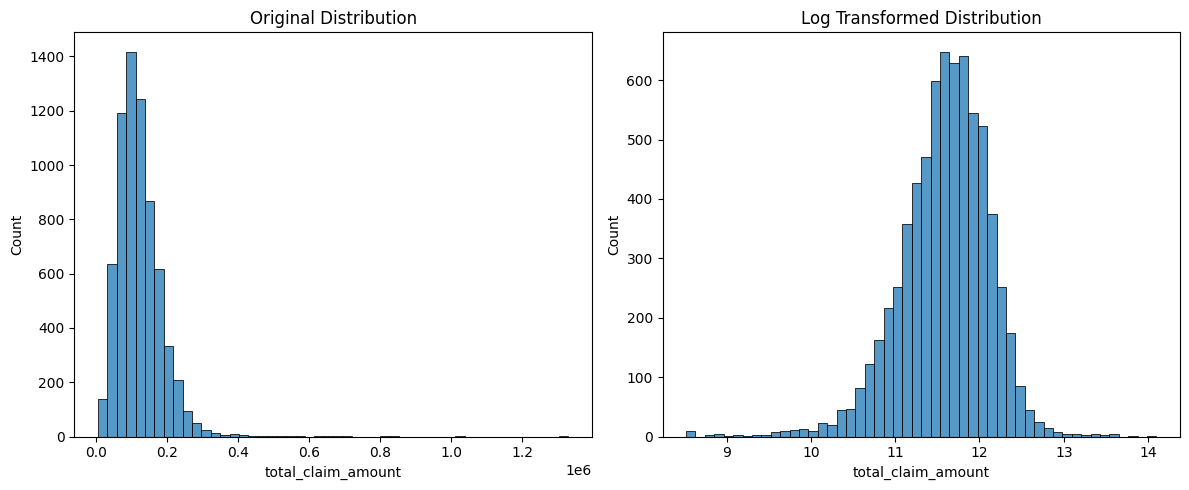

In [67]:
plt.figure(figsize=(12,5))
# Normal distribution
plt.subplot(1,2,1)
sns.histplot(df['total_claim_amount'], bins=50)
plt.title('Original Distribution')

# Log-transformed distribution
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['total_claim_amount']), bins=50)
plt.title('Log Transformed Distribution')

plt.tight_layout()
plt.show()

### Insight:
The distribution of claim amounts is highly right-skewed, indicating that while most claims are relatively low, a small number of high-cost claims significantly increase the overall average.

In [86]:
df['icu_flag'] = df['icu_days'].apply(lambda x: 'ICU' if x > 0 else 'No ICU')
df.groupby('icu_flag')['total_claim_amount'].mean()

,total_claim_amount
icu_flag,
ICU,142457.194606
No ICU,86353.575234


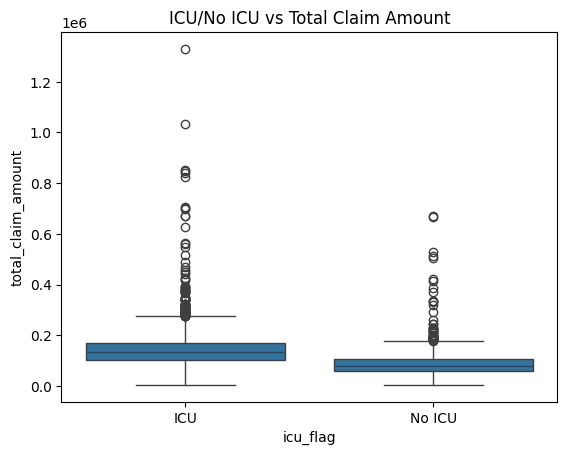

In [94]:
sns.boxplot(x='icu_flag', y='total_claim_amount', data=df)
plt.title('ICU/No ICU vs Total Claim Amount')
plt.show()

### Insight:
ICU patients show significantly higher claim amounts, indicating critical care as a major cost driver.

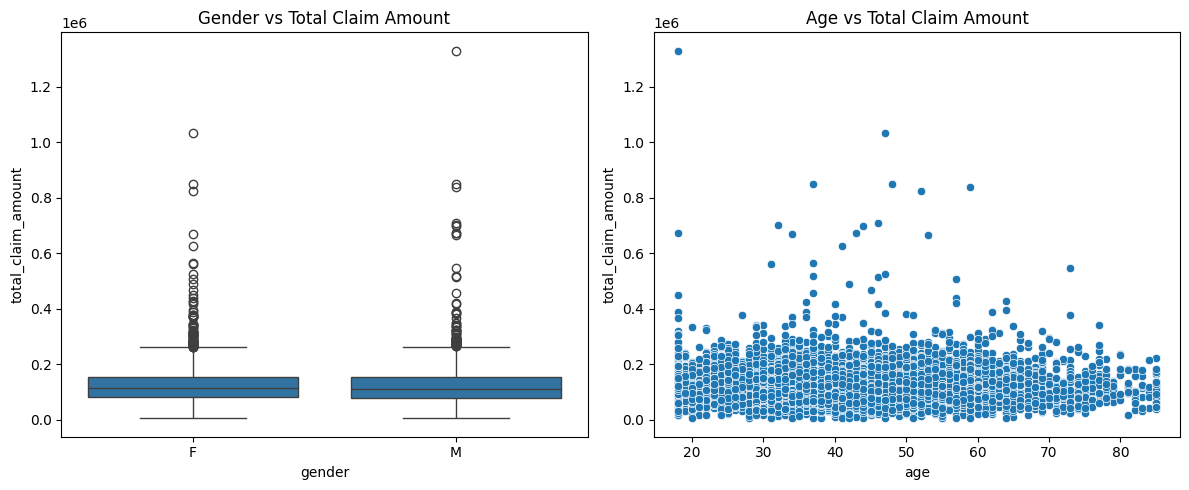

In [92]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='gender', y='total_claim_amount', data=df)
plt.title('Gender vs Total Claim Amount')

plt.subplot(1,2,2)
sns.scatterplot(x='age', y='total_claim_amount', data=df)
plt.title('Age vs Total Claim Amount')

plt.tight_layout()
plt.show()

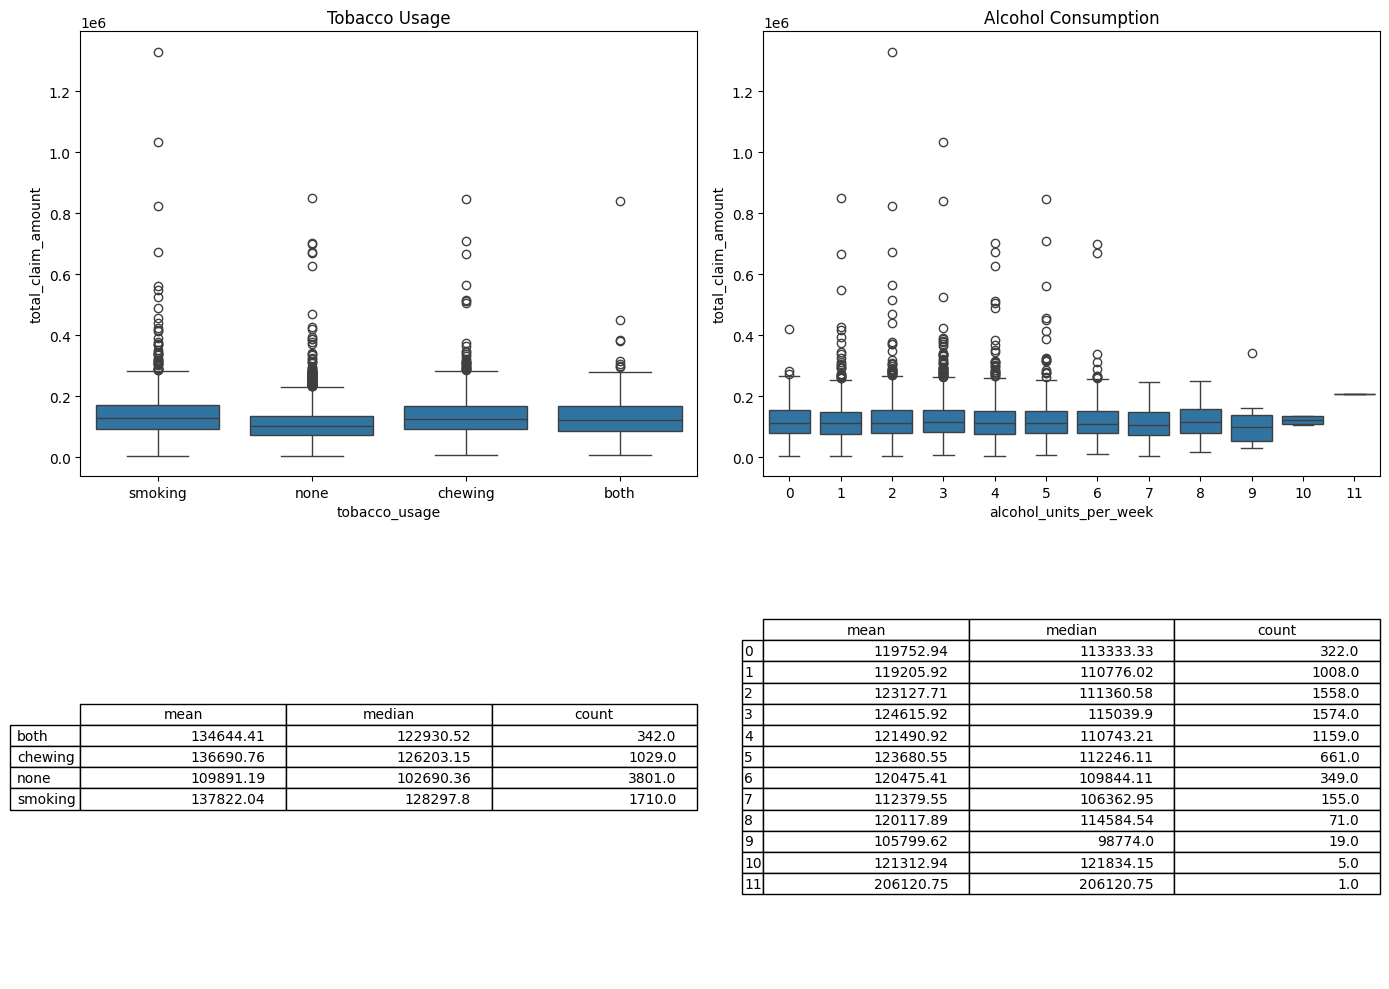

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# --- Top row: plots ---

sns.boxplot(x='tobacco_usage', y='total_claim_amount', data=df, ax=axes[0,0])
axes[0,0].set_title('Tobacco Usage')

sns.boxplot(x='alcohol_units_per_week', y='total_claim_amount', data=df, ax=axes[0,1])
axes[0,1].set_title('Alcohol Consumption')

# --- Bottom row: tables ---

axes[1,0].axis('off')
axes[1,1].axis('off')

tobacco_table = df.groupby('tobacco_usage')['total_claim_amount'].agg(['mean','median','count'])
alcohol_table = df.groupby('alcohol_units_per_week')['total_claim_amount'].agg(['mean','median','count'])

axes[1,0].table(
    cellText=tobacco_table.round(2).values,
    colLabels=tobacco_table.columns,
    rowLabels=tobacco_table.index,
    loc='center'
)

axes[1,1].table(
    cellText=alcohol_table.round(2).values,
    colLabels=alcohol_table.columns,
    rowLabels=alcohol_table.index,
    loc='center'
)

plt.tight_layout()
plt.show()

### Summary of Findings (Health Factors)

- ICU is the strongest driver of high claims  
- Smoking shows moderate impact  
- Tobacco usage increases claim variability

## Key Insights

* Claim amounts are highly right-skewed, with a small number of high-cost cases dominating total expenditure
* ICU stays are the strongest driver of high claim amounts
* Tobacco usage significantly increases healthcare costs
* Claim amounts increase with age, especially for individuals above 45
* High-cost claims are associated with multiple risk factors (ICU + lifestyle + age)
